In [1]:
import os
import numpy as np
import torch

from sensorium.utility import get_data, set_random_seed

from utils import load_model_from_config, get_knn_curve, get_ari_curve
import matplotlib.pyplot as plt

random_seed = 42
set_random_seed(random_seed, deterministic=False)

device = 'cuda:7'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"
# as filenames, we'll select all 7 datasets

filenames = [] 
for file in [
    'static23343-5-17-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static23964-4-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
    'static23656-14-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static21067-10-18-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static22846-10-16-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static27204-5-13-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
]:
    filenames.append(os.path.join(basepath, file))

dataset_fn = "sensorium.datasets.static_loaders"

dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "exclude_eye_position_paths": [
        '/srv/user/polina/sensorium/sensorium/notebooks/data/static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6'
    ],
    "batch_size": 128,
    "scale": 0.25,
}
dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

In [2]:
paths = {
    0.0 : '../training/runs/sigma8/sigma8_seed0',
    0.1 : '../training/runs/entropy/entropy1e-1_seed0',
    1.  : '../training/runs/entropy/entropy1e0_seed0',
    2.  : '../training/runs/entropy/entropy2e0_seed0',
    3.  : '../training/runs/entropy/entropy3e0_seed0',
    5.  : '../training/runs/entropy/entropy5e0_seed0',
    7.  : '../training/runs/entropy/entropy7e0_seed0',
    10. : '../training/runs/entropy/entropy1e1_seed0',
    100.: '../training/runs/entropy/entropy1e2_seed0',
}

models = {}
for sigma, path in paths.items():
    model = load_model_from_config(path, dataloaders, device)
    models[sigma] = model

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [3]:
paths = {}
for w in [1, 2, 3, 5, 7]:
    paths[w] = [
        f'../training/runs/entropy/{w}/entropy{w}_seed0',
        f'../training/runs/entropy/{w}/entropy{w}_seed42',
        f'../training/runs/entropy/{w}/entropy{w}_seed123',
    ]

models = {}
for w, w_paths in paths.items():
    w_models = []
    for path in w_paths:
        model = load_model_from_config(path, dataloaders, device, strict=False)
        w_models.append(model)
    models[w] = w_models

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
P

In [3]:
from sensorium.utility.scores import get_correlations

for sigma, model in models.items():
    print(f'{sigma}: {get_correlations(model, dataloaders['validation'], device=device, per_neuron=False)}')

0.0: 0.4069751501083374
0.1: 0.4069824516773224
1.0: 0.40661048889160156
2.0: 0.4042920470237732
3.0: 0.4030933082103729
5.0: 0.3987218737602234
7.0: 0.39010387659072876
10.0: 0.3470188081264496
100.0: 0.20936539769172668


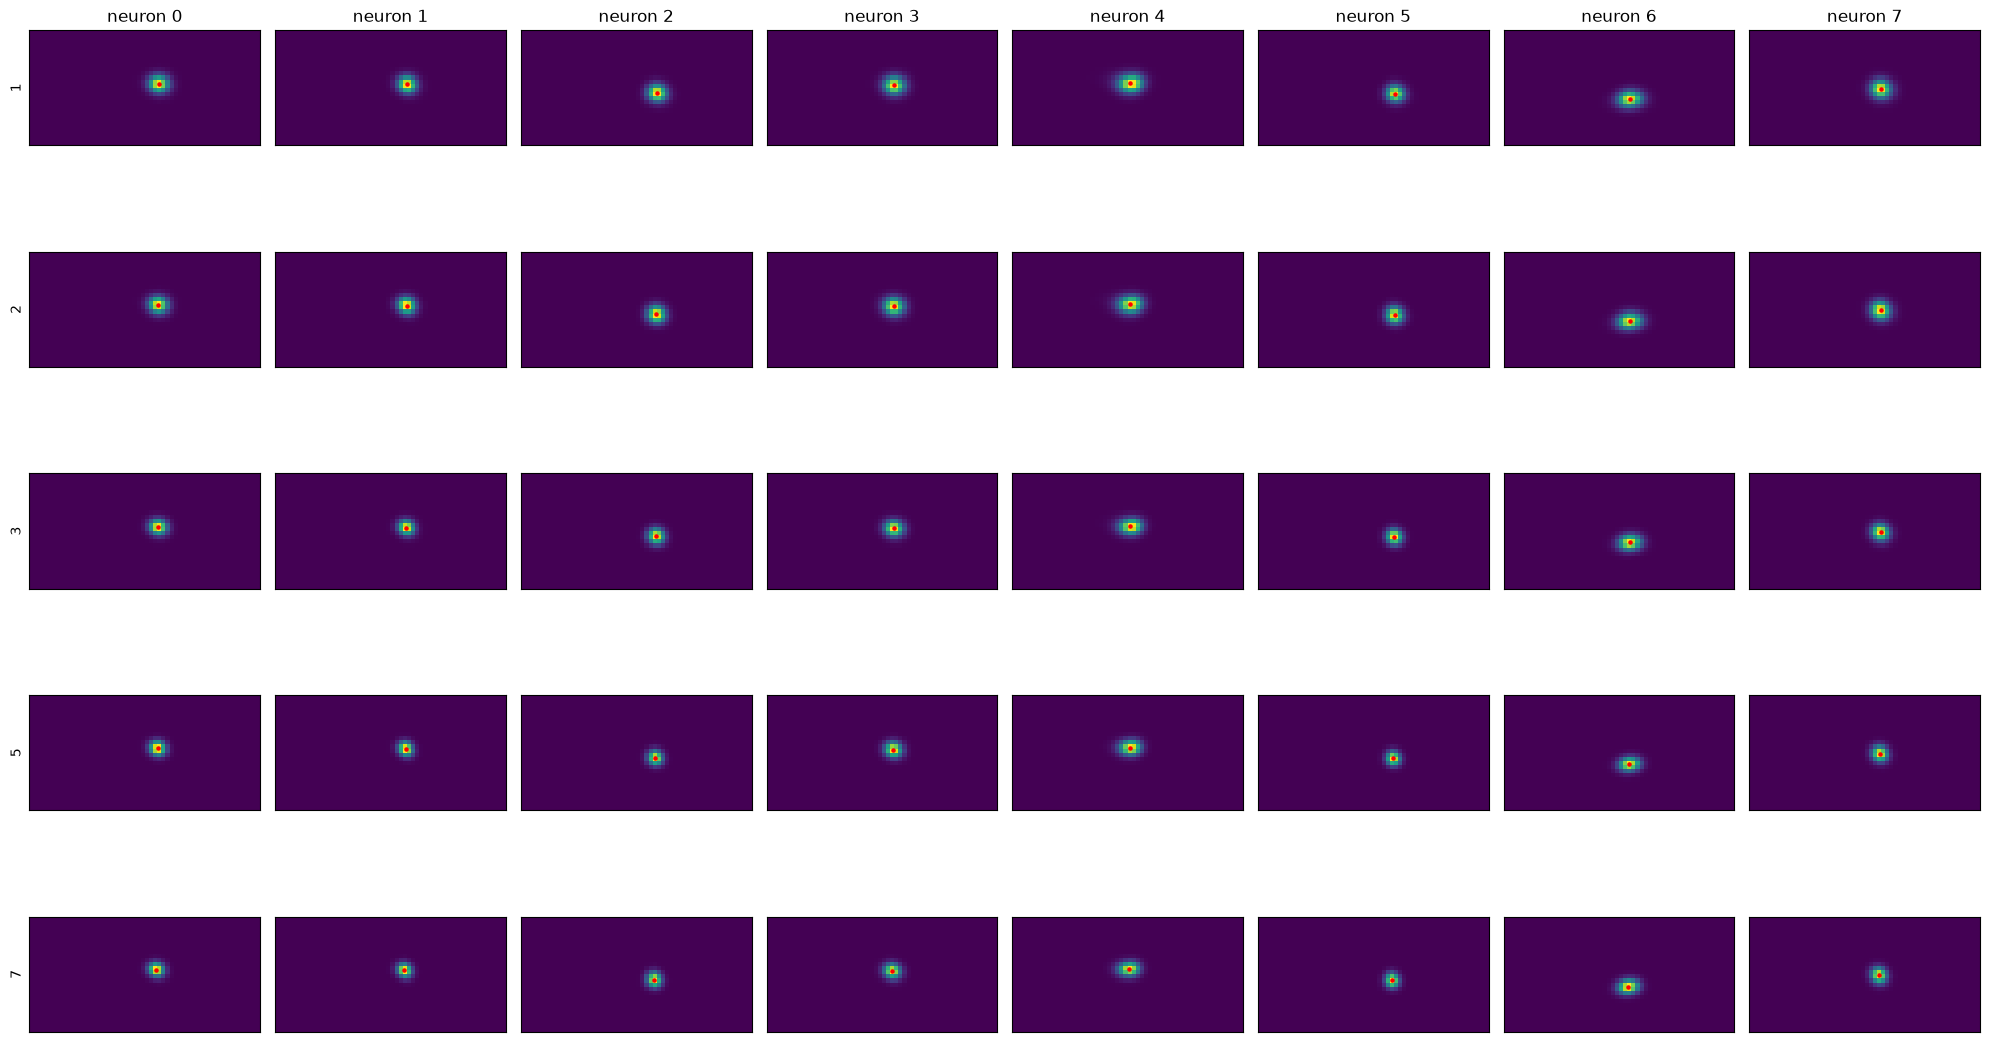

In [5]:
n = 8
fig, axs = plt.subplots(len(models), n, figsize=(20, 12))
neurons = None

for i, (weight, w_models) in enumerate(models.items()):    
    model = w_models[0]
    spatials = torch.cat([model.readout[k].spatial.detach().cpu() for k in [data_keys[0]]])
    neurons = torch.randperm(spatials.shape[0])[:n] if neurons is None else neurons
    for j in range(n):
        ax = axs[i][j]
        spatial = spatials[neurons[j]]

        h, w = spatial.shape
        y = spatial.sum(dim=1)  # h
        x = spatial.sum(dim=0)  # w

        y_pos = torch.arange(h)
        x_pos = torch.arange(w)

        y_avg = (y_pos * y).sum()
        x_avg = (x_pos * x).sum()

        ax.imshow(spatial)
        ax.scatter(x_avg, y_avg, s=5, color='red')
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0:
            ax.set_title(f'neuron {j}')
        if j == 0:
            ax.set_ylabel(weight)

plt.tight_layout()

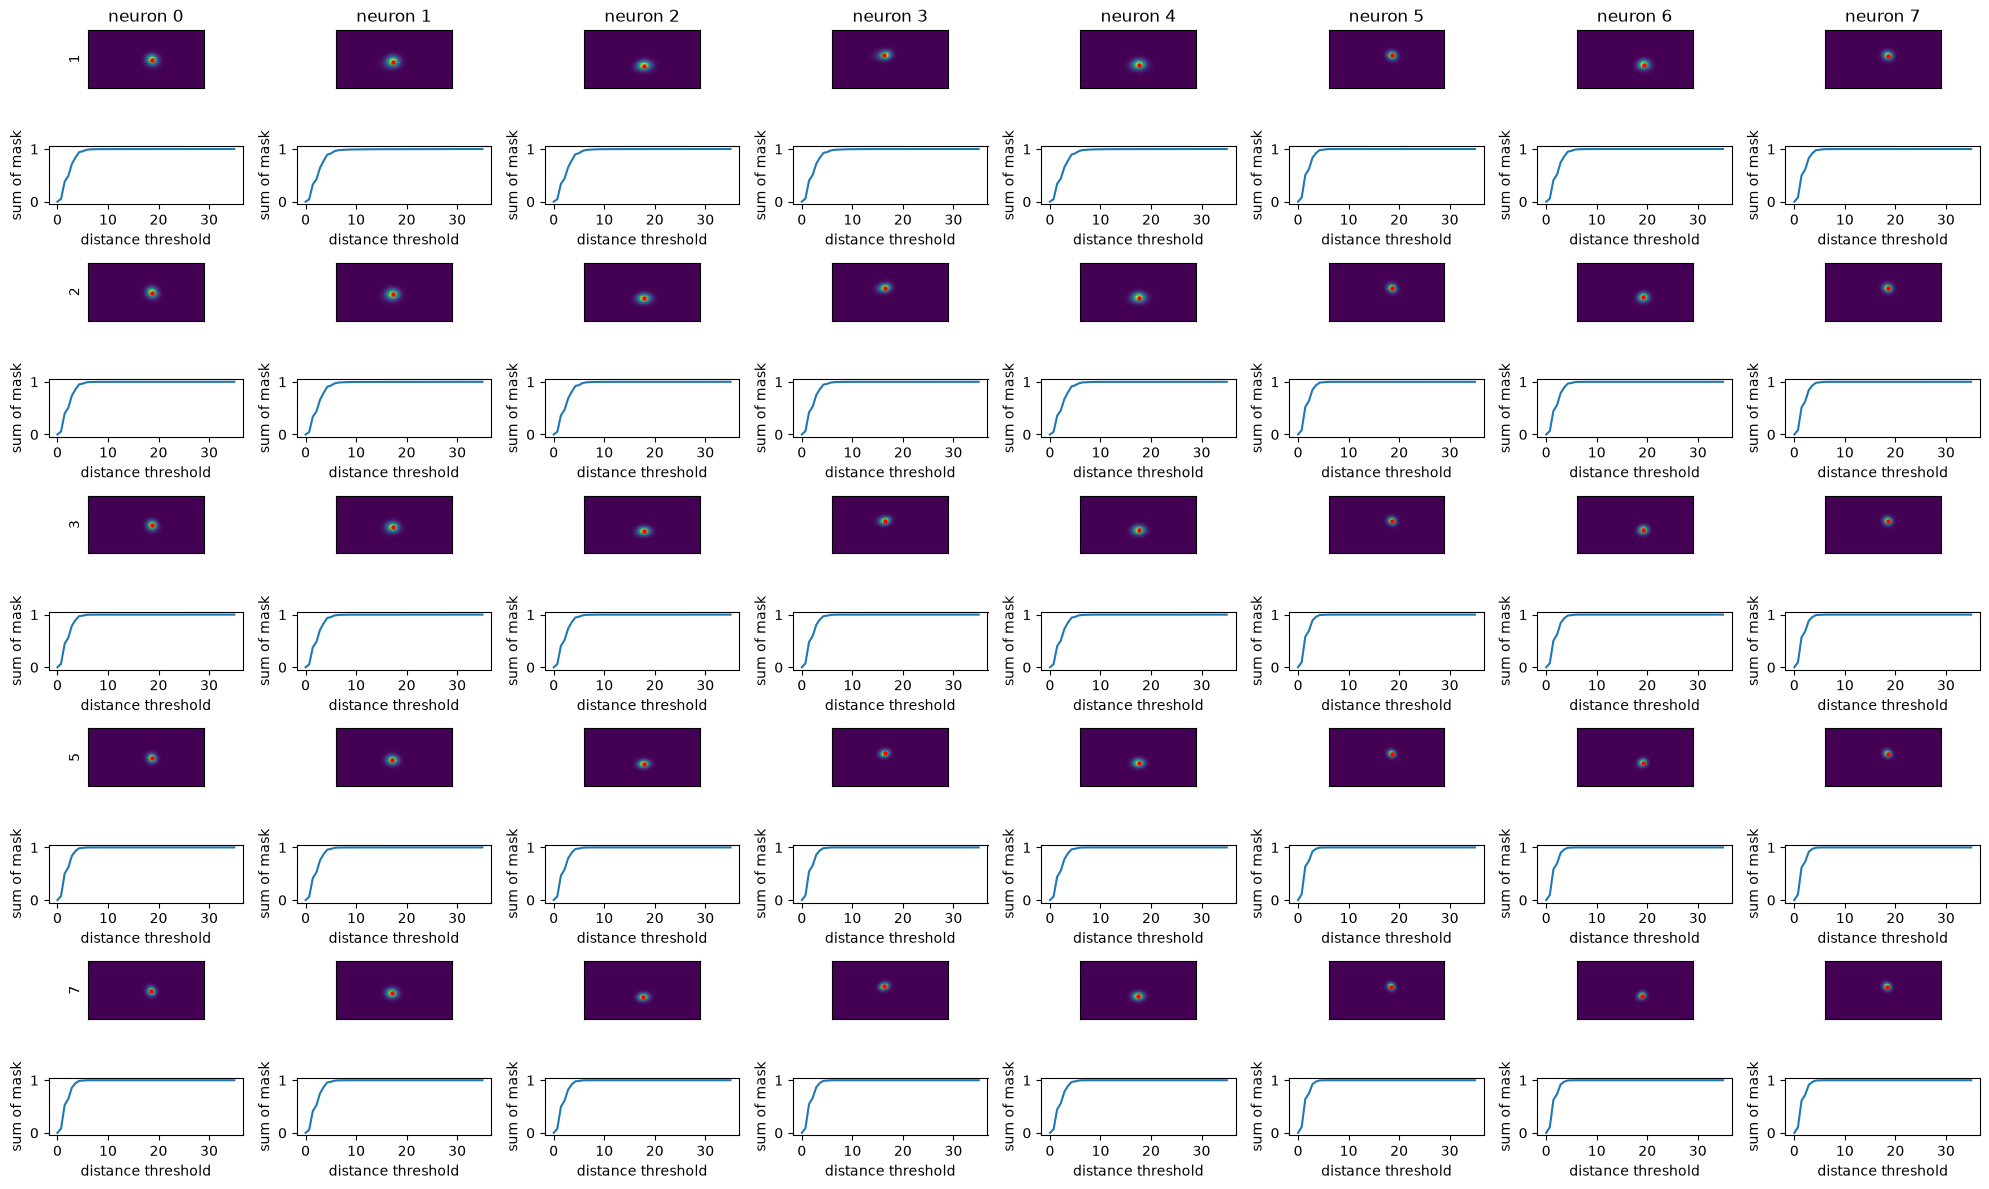

In [8]:
n = 8
fig, axs = plt.subplots(len(models) * 2, n, figsize=(20, 12))
neurons = None

for i, (weight, w_models) in enumerate(models.items()):    
    model = w_models[0]
    spatials = torch.cat([model.readout[k].spatial.detach().cpu() for k in [data_keys[6]]])
    neurons = torch.randperm(spatials.shape[0])[:n] if neurons is None else neurons
    for j in range(n):
        ax = axs[i * 2][j]
        spatial = spatials[neurons[j]]

        h, w = spatial.shape
        y = spatial.sum(dim=1)  # h
        x = spatial.sum(dim=0)  # w

        y_pos = torch.arange(h)
        x_pos = torch.arange(w)

        y_avg = (y_pos * y).sum()
        x_avg = (x_pos * x).sum()

        ax.imshow(spatial)
        ax.scatter(x_avg, y_avg, s=5, color='red')
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0:
            ax.set_title(f'neuron {j}')
        if j == 0:
            ax.set_ylabel(weight)

        y_max = y.argmax()
        x_max = x.argmax()

        y_dist = (y_pos - y_max).pow(2)
        x_dist = (x_pos - x_max).pow(2)

        yy, xx = torch.meshgrid(y_dist, x_dist, indexing='ij')
        dists = torch.stack([xx, yy], dim=-1).sum(-1).sqrt()

        thresholds = torch.linspace(0, 35, steps=50)
        volumes = []
        for t in thresholds:
            vol = spatial[dists < t].sum()
            volumes.append(vol)
        
        ax = axs[i * 2 + 1][j]
        ax.plot(thresholds, volumes)
        ax.set_xlabel('distance threshold')
        ax.set_ylabel('sum of mask')

plt.tight_layout()

In [9]:
full_grids = {}
for sigma, sigma_models in models.items():
    sigma_grids = []
    for model in sigma_models:
        grids = []
        for key in data_keys:
            spatial = model.readout[key].spatial.detach().cpu()
            n, h, w = spatial.shape
            y = spatial.sum(dim=2)  # n, h
            x = spatial.sum(dim=1)  # n, w

            y_pos = torch.arange(h).unsqueeze(0).expand(n, h)
            x_pos = torch.arange(w).unsqueeze(0).expand(n, w)

            y_avg = (y_pos * y).sum(dim=1)
            x_avg = (x_pos * x).sum(dim=1)
            
            grid = torch.stack([x_avg, y_avg], dim=1)
            grids.append(grid)
        sigma_grids.append(grids)

    full_grids[sigma] = sigma_grids

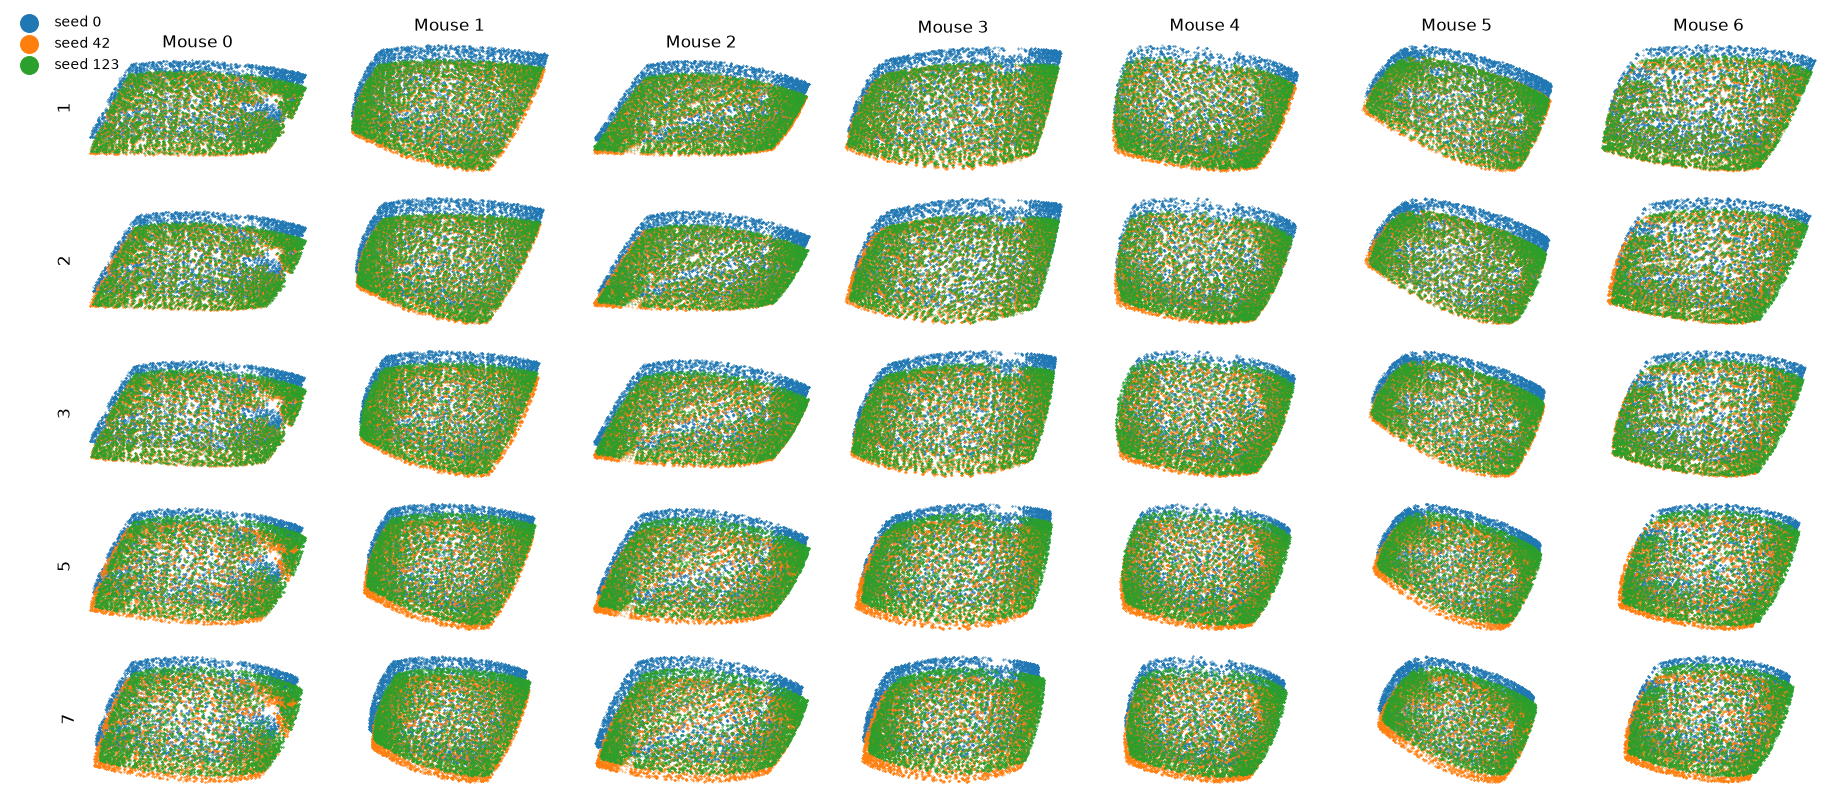

In [10]:
model_seeds = [0, 42, 123]
model_types = full_grids

num_mice = 7
num_models = len(model_seeds)

fig, axs = plt.subplots(len(model_types), num_mice, figsize=(18, 8))

for row_idx, (type_name, grids) in enumerate(full_grids.items()):
    for mouse_idx in range(num_mice):
        ax = axs[row_idx, mouse_idx]
        for model_idx in range(num_models):
            grid = grids[model_idx][mouse_idx]
            ax.scatter(
                grid[:, 0], grid[:, 1],
                alpha=1, s=0.1,
                label=f"seed {model_seeds[model_idx]}",
            )
        ax.set_aspect('equal')

        # remove spines and ticks
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])

        # column labels on top row only
        if row_idx == 0:
            ax.set_title(f"Mouse {mouse_idx}")

        # row labels on first column only
        if mouse_idx == 0:
            ax.set_ylabel(type_name, rotation=90, size='large')

# single shared legend for seeds (bigger markers than the tiny scatter points)
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    bbox_to_anchor=(0.05, 1.0),
    markerscale=40,
    frameon=False,
)

plt.tight_layout()
plt.show()

In [11]:
curves = {}
for sigma, sigma_models in models.items():
    readouts = []
    for model in sigma_models:
        r = torch.cat([model.readout[key].features.detach() for key in data_keys])
        r = model.whitener.transform_weights(r.T).T.cpu()
        readouts.append(r)

    curve, k_range = get_knn_curve(readouts)
    curves[sigma] = curve

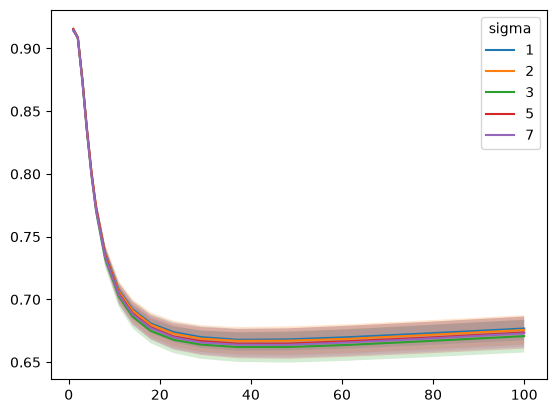

In [14]:
for sigma, curve in curves.items():
    m, s = curve[0], curve[1]
    plt.plot(k_range, m, label=sigma)
    plt.fill_between(k_range, m - s, m + s, alpha=0.2)

plt.legend(title='sigma')
plt.show()